# Notebook 3 - Feature Analysis

## Feature Analysis Setup

This section initialises the environment for feature analysis by importing the required libraries and loading project configuration parameters. The selected libraries support statistical analysis, feature extraction, and basic modelling, enabling deeper investigation of relationships between features and the target variable.

Configuration variables are loaded from a central module to ensure consistency across experiments, including dataset paths, linguistic cue lists, and reproducibility settings. This modular approach improves maintainability and allows easy adjustments without modifying core code.

Additionally, plotting aesthetics are standardised for consistency across visualisations, and a dedicated directory is created to store feature analysis outputs. A predefined colour palette is also set for consistent representation of class labels.

In [1]:
# System path setup
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from collections import Counter

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Project configuration
from config import (
    LABELLED_DATASET,  
    VISUALISATION_DIR,         
    NEGATION_CUES,     
    INTENSIFIERS,      
    RANDOM_STATE,      
)

# Create directory for feature analysis outputs
FEAT_DIR = VISUALISATION_DIR / 'feature_analysis'
os.makedirs(FEAT_DIR, exist_ok=True)

# Global plotting style
plt.rcParams.update({
    'figure.dpi' : 120,
    'font.size' : 12,
    'axes.spines.top' : False,
    'axes.spines.right' : False,
    'axes.grid' : True,
    'grid.alpha' : 0.25,
    'grid.linestyle' : ':',
})

# Class-wise colour palette
PALETTE = {
    'suicide': '#C1121F',
    'non-suicide': '#0077B6'
}

## Loading Processed Dataset

This section loads the preprocessed dataset containing all splits and separates it into training, validation, and test subsets based on the split identifier. This approach ensures consistency with earlier preprocessing steps and avoids redundant data splitting.

Each subset is stored independently to facilitate downstream analysis and model development. The sizes of the splits are displayed to confirm correct loading and partitioning.

In [2]:
# Load processed dataset
df = pd.read_csv(LABELLED_DATASET)

# Split into train, validation, and test sets
train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()
test  = df[df['split'] == 'test'].copy()

# Display split sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 13,467  Val: 3,517  Test: 2,998


## TF-IDF Feature Extraction

This section converts the cleaned text into numerical features using the TF-IDF (Term Frequency–Inverse Document Frequency) representation. TF-IDF captures the importance of words and phrases by balancing their frequency within a document against their rarity across the corpus.

The vectoriser is fitted only on the training data to avoid data leakage. Both unigrams and bigrams are included to capture individual terms as well as short contextual phrases. Additional parameters such as minimum document frequency and sublinear term scaling help reduce noise and improve feature quality.

The resulting sparse matrix represents each document in a high-dimensional feature space, ready for modelling and further analysis.

In [3]:
# Fit TF-IDF on training text
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=5
)

# Transform training data
X_train_tfidf = tfidf.fit_transform(train['text_clean'])
y_train = train['label_id'].values

# Display matrix shape
print(f'TF-IDF matrix: {X_train_tfidf.shape}')

TF-IDF matrix: (13467, 20000)


## Feature Importance via Logistic Regression

This section uses logistic regression coefficients as a proxy for feature importance. After training a linear model on TF-IDF features, the learned coefficients indicate how strongly each term contributes to predicting a particular class.

Positive coefficients are associated with the suicide class, while negative coefficients correspond to the non-suicide class. By ranking these coefficients, the most influential words and phrases for each class can be identified.

This analysis provides interpretable insights into which linguistic patterns are most discriminative in the dataset.

In [4]:
# Train logistic regression model
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr.fit(X_train_tfidf, y_train)

# Extract feature names and coefficients
feature_names = tfidf.get_feature_names_out()
coefs = lr.coef_[0]

# Identify top features for each class
top_k = 20

top_suicide_idx = coefs.argsort()[-top_k:][::-1]
top_nonsuicide_idx = coefs.argsort()[:top_k]

top_suicide = pd.DataFrame({
    'feature': feature_names[top_suicide_idx],
    'coefficient': coefs[top_suicide_idx]
})

top_nonsuicide = pd.DataFrame({
    'feature': feature_names[top_nonsuicide_idx],
    'coefficient': coefs[top_nonsuicide_idx]
})

# Display top features
print('Top 10 features (Suicide Class):')
print(top_suicide.head(10).to_string(index=False))
print()

print('Top 10 features (Non-Suicide Class):')
print(top_nonsuicide.head(10).to_string(index=False))

Top 10 features (Suicide Class):
 feature  coefficient
 suicide     7.678008
suicidal     5.940173
    life     5.481075
     die     5.356369
  myself     5.090874
    kill     4.995369
      to     4.058524
    feel     4.014914
     end     3.780191
     can     3.672908

Top 10 features (Non-Suicide Class):
feature  coefficient
     we    -2.572355
    you    -2.550755
   guys    -2.437240
   your    -2.376643
  bored    -2.348918
   like    -2.340284
 school    -2.329748
  crush    -2.246869
   yeah    -2.174029
   girl    -2.148505


## TF-IDF Feature Importance

This section visualises the most influential features derived from TF-IDF representations. Feature importance is based on the magnitude of model coefficients, indicating the strength of association with each class.

The top features for each class are presented separately to highlight discriminative terms. Absolute coefficient values are used to focus on importance rather than direction.

This analysis provides insight into which words contribute most strongly to model predictions and helps interpret model behaviour.

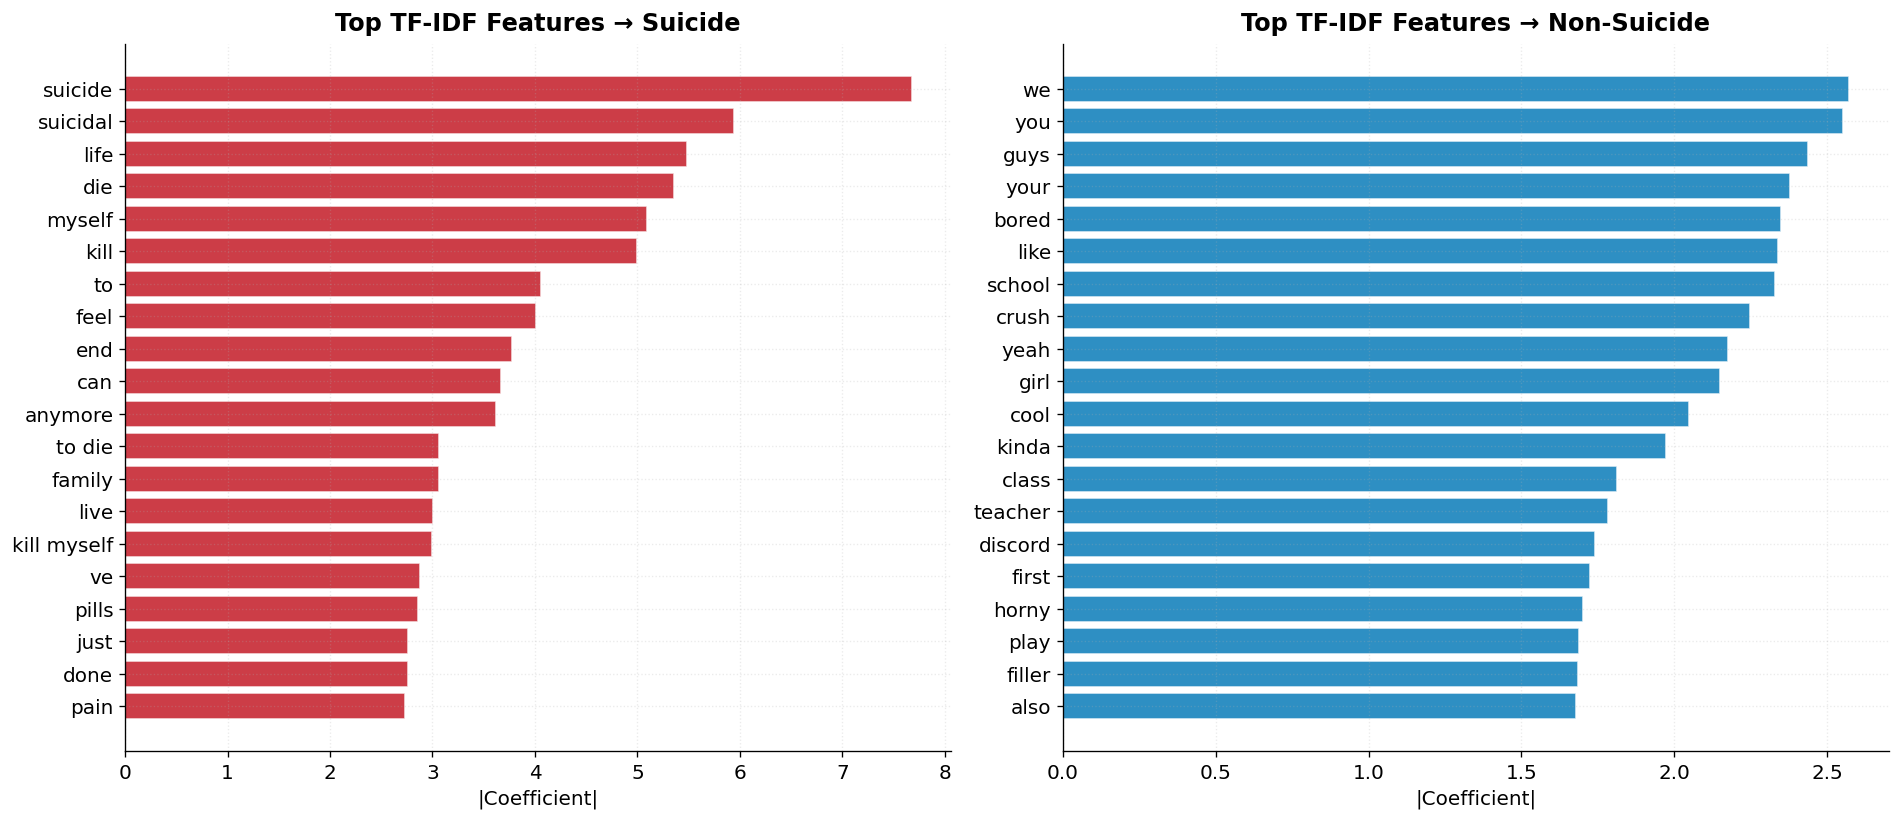

In [5]:
# Subplot layout for class-wise feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Horizontal bar charts for top TF-IDF features
for ax, data, title, color in zip(
    axes,
    [top_suicide, top_nonsuicide],
    ['Top TF-IDF Features → Suicide', 'Top TF-IDF Features → Non-Suicide'],
    ['#C1121F', '#0077B6']
):
    ax.barh(
        data['feature'][::-1],
        data['coefficient'].abs()[::-1],
        color=color,
        alpha=0.82,
        edgecolor='white'
    )
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('|Coefficient|')

# Layout adjustment and figure saved
plt.tight_layout()
plt.savefig(
    FEAT_DIR / 'tfidf_feature_importance.png',
    bbox_inches='tight'
)
plt.show()

## Statistical Comparison of Linguistic Features

This section evaluates whether linguistic feature distributions differ significantly between classes. A non-parametric Mann–Whitney U test is applied, as it does not assume normality.

The test is performed on selected ratio-based features, comparing their distributions across the two classes. This helps determine whether observed differences are statistically meaningful.

The reported statistics provide evidence on whether these features contribute discriminative information for classification.

In [6]:
# Header for statistical test results
print(f'  {"Feature":<20}  {"U-stat":>12}  {"p-value":>12} ')
print('  ' + '─' * 60)

# Mann–Whitney U test applied to selected features
for feat in ['neg_ratio', 'intens_ratio']:
    if feat not in train.columns:
        print(f'  {feat:<20}  (column not found — skipping)')
        continue

    # Class-wise samples extracted
    g_s  = train[train['label'] == 'suicide'][feat].dropna()
    g_ns = train[train['label'] == 'non-suicide'][feat].dropna()

    # Non-parametric test computed
    stat, p = stats.mannwhitneyu(
        g_s,
        g_ns,
        alternative='two-sided'
    )

    # Results displayed in formatted output
    print(f'  {feat:<20}  {stat:>12.0f}  {p:>12.4e}')

  Feature                     U-stat       p-value 
  ────────────────────────────────────────────────────────────
  neg_ratio                 32369608    0.0000e+00
  intens_ratio              27416388   1.7765e-107


## Distribution of Linguistic Features

This section visualises the distribution of selected linguistic features across classes using violin plots. These plots combine density estimation with summary statistics, offering a detailed view of feature behaviour.

To reduce the influence of extreme values, features are clipped at a high percentile before plotting. This ensures that the distributions remain interpretable and comparable.

The visual comparison highlights differences in central tendency and spread, helping assess the discriminative potential of these features.

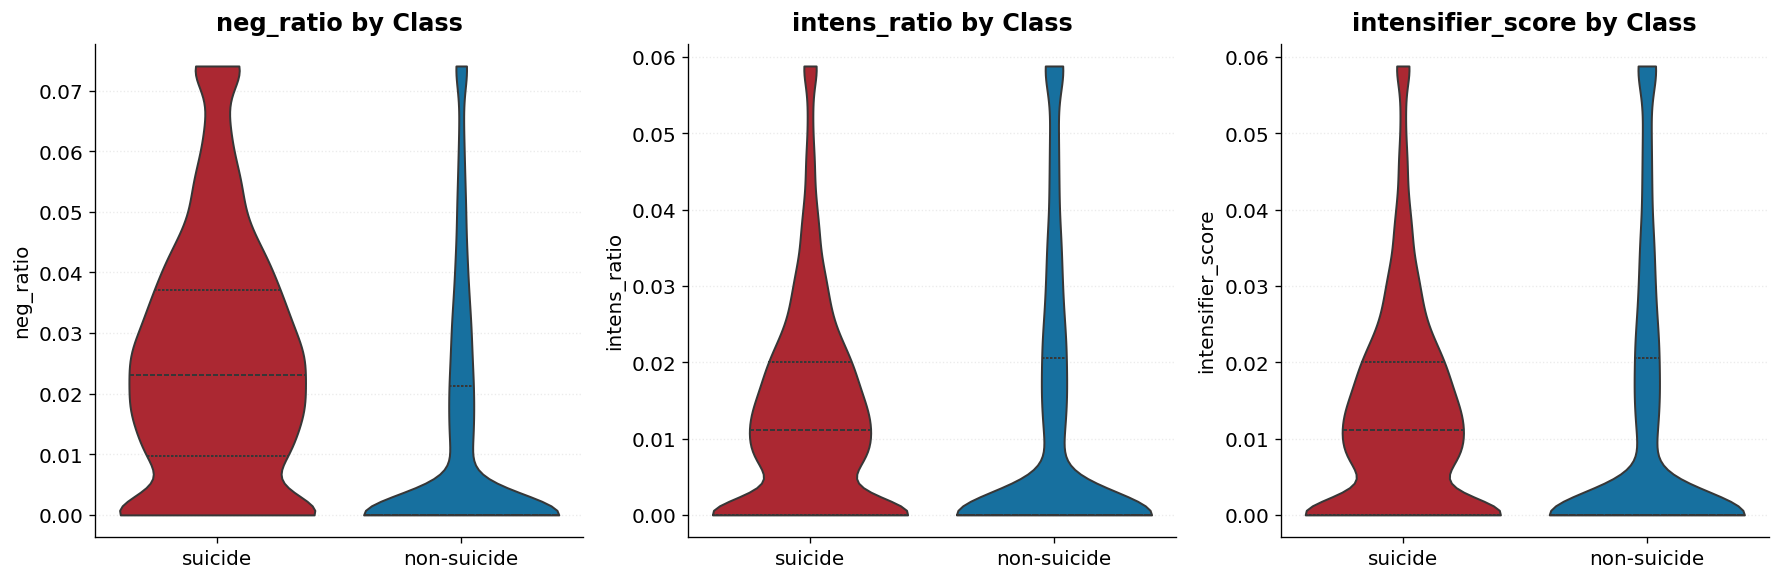

In [7]:
# Selection of available linguistic features for plotting
features_to_plot = [
    c for c in ['neg_ratio', 'intens_ratio', 'intensifier_score']
    if c in train.columns
]

# Violin plots generated when features are present
if features_to_plot:
    fig, axes = plt.subplots(
        1,
        len(features_to_plot),
        figsize=(5 * len(features_to_plot), 5)
    )

    # Axis handling for single feature case
    if len(features_to_plot) == 1:
        axes = [axes]

    # Plotting each feature distribution
    for ax, feat in zip(axes, features_to_plot):
        plot_df = train[['label', feat]].copy()
        plot_df[feat] = plot_df[feat].clip(
            upper=plot_df[feat].quantile(0.97)
        )
        sns.violinplot(
            data=plot_df,
            x='label',
            y=feat,
            ax=ax,
            palette=PALETTE,
            inner='quartile',
            linewidth=1.2,
            cut=0
        )
        ax.set_title(f'{feat} by Class', fontweight='bold', pad=8)
        ax.set_xlabel('')
        ax.set_axisbelow(True)

    # Layout adjustment and figure saved
    plt.tight_layout()
    plt.savefig(
        FEAT_DIR / 'linguistic_violins.png',
        bbox_inches='tight'
    )
    plt.show()

## Negation Cue Distribution Across Classes

This section examines how individual negation cues are distributed between classes. By counting occurrences within each class, it becomes possible to identify cues that appear more frequently in one group than the other.

A combined table is constructed to align cue frequencies from both classes. A ratio metric is then computed to capture relative differences, with smoothing applied to handle zero counts.

The sorted results highlight cues that are more strongly associated with one class, providing additional insight into linguistic patterns in the dataset.

In [8]:
# Frequency counts of cues within a subset
def cue_frequency(df_subset, cue_list):
    counter = Counter()
    for text in df_subset['text_clean']:
        tokens = str(text).split()
        for t in tokens:
            if t in cue_list:
                counter[t] += 1
    return counter

# Cue frequencies computed per class
neg_suicide = cue_frequency(
    train[train['label'] == 'suicide'],
    NEGATION_CUES
)

neg_nonsuicide = cue_frequency(
    train[train['label'] == 'non-suicide'],
    NEGATION_CUES
)

# Combined cue table constructed
neg_df = pd.DataFrame({
    'cue': list(set(neg_suicide.keys()) | set(neg_nonsuicide.keys()))
})
neg_df['suicide_freq'] = neg_df['cue'].map(neg_suicide).fillna(0)
neg_df['nonsuicide_freq'] = neg_df['cue'].map(neg_nonsuicide).fillna(0)

# Ratio reflecting relative association
neg_df['ratio'] = (
    (neg_df['suicide_freq'] + 1) /
    (neg_df['nonsuicide_freq'] + 1)
)
neg_df = neg_df.sort_values(
    'ratio',
    ascending=False
).reset_index(drop=True)

# Top cues skewed toward suicide class
print('Negation cues most skewed toward suicide class:')
print(
    neg_df.head(10)
    .to_string(index=False)
)

Negation cues most skewed toward suicide class:
     cue  suicide_freq  nonsuicide_freq    ratio
   can't          3287              339 9.670588
   won't           692               95 7.218750
 haven't           492               68 7.144928
  cannot           327               47 6.833333
 nothing          1601              234 6.817021
   don't          6798             1007 6.745040
couldn't           436               65 6.621212
     nor           101               15 6.375000
wouldn't           378               60 6.213115
  nobody           492               81 6.012195


## Comparison of Negation Cue Frequencies

This section visualises the most prominent negation cues and compares their frequencies across classes. The focus is on cues that exhibit the strongest imbalance based on the previously computed ratio.

A grouped bar chart is used to display class-wise counts for each cue, enabling direct comparison. This representation highlights which cues are more prevalent in one class relative to the other.

The visualisation supports interpretation of linguistic patterns and helps identify features that may contribute to class separation.

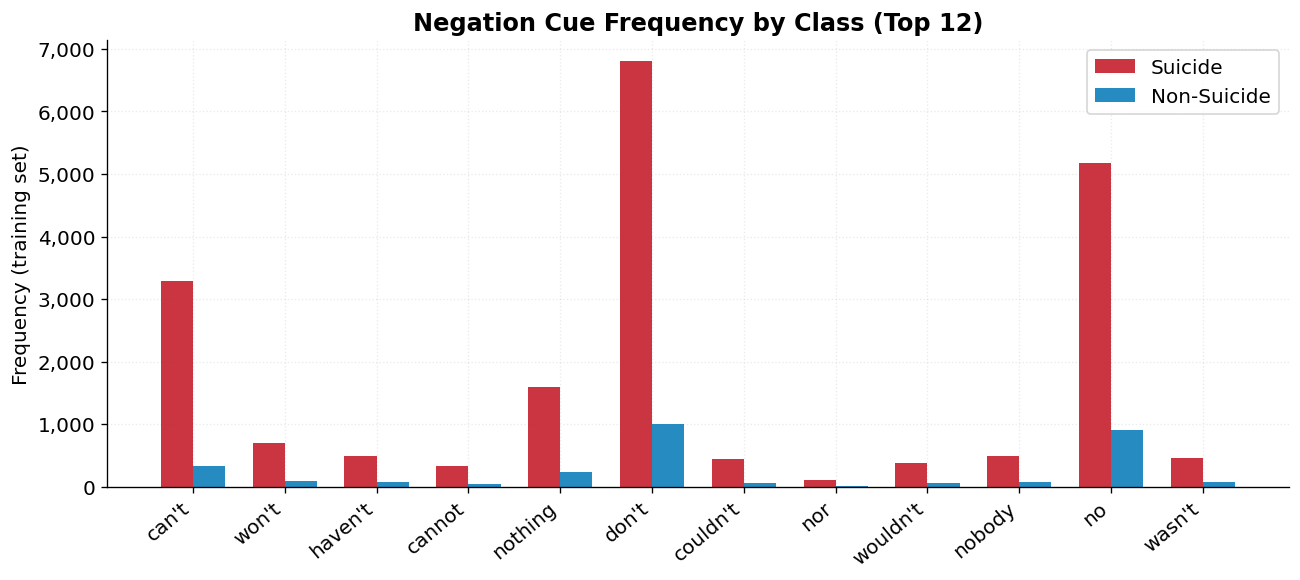

In [9]:
# Top cues selected based on skew ratio
top_cues = neg_df.head(12)
x, w = np.arange(len(top_cues)), 0.35

# Grouped bar chart for class-wise comparison
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    x - w / 2,
    top_cues['suicide_freq'],
    w,
    label='Suicide',
    color='#C1121F',
    alpha=0.85
)
ax.bar(
    x + w / 2,
    top_cues['nonsuicide_freq'],
    w,
    label='Non-Suicide',
    color='#0077B6',
    alpha=0.85
)

# Axis formatting and labels
ax.set_xticks(x)
ax.set_xticklabels(
    top_cues['cue'],
    rotation=40,
    ha='right'
)
ax.set_ylabel('Frequency (training set)')
ax.set_title(
    'Negation Cue Frequency by Class (Top 12)',
    fontweight='bold'
)
ax.legend()
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Layout adjustment and figure saved
plt.tight_layout()
plt.savefig(
    FEAT_DIR / 'negation_cue_frequency.png',
    bbox_inches='tight'
)
plt.show()

## Intensifier Usage Comparison

This section evaluates how individual intensifiers differ in usage across classes. Frequencies are normalised to account for class size, allowing fair comparison between groups.

A log-ratio metric is computed to quantify relative differences, where positive values indicate higher prevalence in one class and negative values indicate the opposite. Smoothing is applied to ensure numerical stability.

The resulting visualisation highlights intensifiers that are more characteristic of each class, providing insight into expressive patterns within the data.

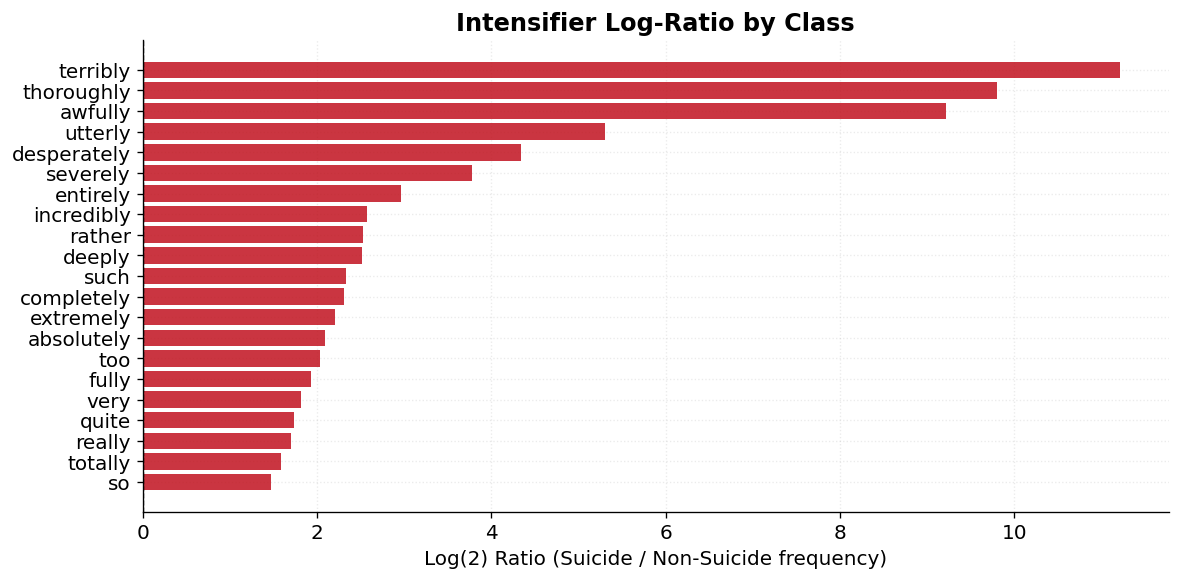

In [10]:
# Intensifier frequencies computed per class
int_suicide = cue_frequency(
    train[train['label'] == 'suicide'],
    INTENSIFIERS
)

int_nonsuicide = cue_frequency(
    train[train['label'] == 'non-suicide'],
    INTENSIFIERS
)

# Class sizes used for normalisation
n_s  = len(train[train['label'] == 'suicide'])
n_ns = len(train[train['label'] == 'non-suicide'])

# Frequency table constructed for all intensifiers
int_df = pd.DataFrame({'word': INTENSIFIERS})
int_df['suicide_count'] = int_df['word'].map(int_suicide).fillna(0)
int_df['nonsuicide_count'] = int_df['word'].map(int_nonsuicide).fillna(0)

# Percentage-based representation
int_df['suicide_pct'] = int_df['suicide_count'] / n_s
int_df['nonsuicide_pct'] = int_df['nonsuicide_count'] / n_ns

# Log-ratio capturing relative importance
EPS = 1e-6
int_df['log_ratio'] = np.log2(
    (int_df['suicide_pct'] + EPS) /
    (int_df['nonsuicide_pct'] + EPS)
)

# Sorting based on log-ratio magnitude
int_df = int_df.sort_values(
    'log_ratio',
    ascending=False
)

# Horizontal bar plot for comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = [
    '#C1121F' if r > 0 else '#0077B6'
    for r in int_df['log_ratio']
]

ax.barh(
    int_df['word'][::-1],
    int_df['log_ratio'][::-1],
    color=colors[::-1],
    alpha=0.85
)

# Reference line at zero for neutrality
ax.axvline(
    0,
    color='black',
    linewidth=0.8,
    linestyle='--'
)
ax.set_xlabel('Log(2) Ratio (Suicide / Non-Suicide frequency)')
ax.set_title(
    'Intensifier Log-Ratio by Class',
    fontweight='bold'
)
ax.set_axisbelow(True)

# Layout adjustment and figure saved
plt.tight_layout()
plt.savefig(
    FEAT_DIR / 'intensifier_log_ratio.png',
    bbox_inches='tight'
)
plt.show()